# Module 2: Feature EDA

This notebook transforms raw OHLCV data into predictive features and selects the final feature set used for model training.

**Pipeline:**
1. Build candidate features from raw OHLCV (momentum, volatility, trend, WorldQuant alphas)
2. Measure each feature's predictive power via IC/IR analysis
3. Remove redundant features using Spearman correlation pruning

**Input:** `data/market_data.parquet`  
**Output:** `data/featured_data.parquet` — full dataframe with all features and targets, ready for model training

> **Note:** Feature selection (IC/IR analysis, correlation pruning) is done on the **full dataset** here for exploration. The walk-forward CV in notebook 03  is where selection now happens via `icir_filter=True`.

## 2.1 Imports and Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import sys
import os

project_root = os.path.abspath('../')
if project_root not in sys.path:
    sys.path.append(project_root)

import src.features as ft
import src.evaluation as ev
import src.feature_search as fs
from config import candidate_features, final_features

## 2.2 Data Loading

In [ ]:
FILE_PATH = '../data/market_data.parquet'
df_raw = pd.read_parquet(FILE_PATH)
df_raw = df_raw[df_raw['close'] > 0].copy()

print(f'Shape          : {df_raw.shape}')
print(f'Date range     : {df_raw["date"].min()} → {df_raw["date"].max()}')
print(f'Unique tickers : {df_raw["Symbol"].nunique()}')
df_raw.head()

Shape          : (688709, 7)
Date range     : 2016-01-04 00:00:00 → 2026-05-20 00:00:00
Unique tickers : 300


,date,open,high,low,close,volume,Symbol
0,2016-01-04,6.08,6.22,6.02,6.17,324250,AAA
1,2016-01-05,6.13,6.66,6.07,6.61,1842018,AAA
2,2016-01-06,6.13,6.66,6.07,6.61,249405,AAA
3,2016-01-07,6.48,6.61,6.32,6.46,334090,AAA
4,2016-01-08,6.48,6.61,6.32,6.46,168020,AAA


## 2.3 Feature & Target Construction

We build three layers on top of raw OHLCV:
- **Features** — all candidate signals (momentum, volatility, trend, WQ alphas)
- **Targets** — forward returns (`next_1m_ret`, etc.) used as the prediction objective  
- **Ranking labels** — quintile labels (1–5) used as the LambdaRank supervision signal

**Candidate feature groups:**
- **Momentum**: `log_ret_1w/1m/3m/6m/1y`, `log_ret_skip1m` — short- to long-horizon return signals and skip-month reversal
- **Volatility**: `volatility_1w/1m/3m/6m`, `volatility_shock_weekly/monthly` — realized risk and regime shifts
- **Trend & Liquidity**: `dist_SMA/EMA`, `dist_52w_high`, `RSI_14`, `volume_surge`, `obv_trend`, `price_vol_divergence`
- **WorldQuant Alphas**: formulaic signals from the WorldQuant 101 library capturing market microstructure effects

In [7]:
df = ft.build_features(df_raw)
df = ft.build_targets(df)
df = ft.target_generating_ranking(df)

features = candidate_features
print(f'Candidate features : {len(features)}')
print(f'Dataset shape      : {df.shape}')

Generating WorldQuant Alphas...


Dropping 2 date(s) with fewer than 50 stocks after NaN removal.


Candidate features : 46
Dataset shape      : (605950, 72)


## 2.4 IC / IR Analysis — Feature Predictive Power

We measure each feature's predictive power using **Information Coefficient (IC)** — the Spearman rank correlation between a feature and next-month forward return, computed cross-sectionally per date.

Three summary metrics:
- **IC Mean** — average predictive power across all dates
- **IC Std** — consistency of the signal over time
- **IC IR** (= IC Mean / IC Std) — risk-adjusted signal quality; higher = more reliable

We use `|IC IR| > 0.02` as the minimum bar to keep a feature.

In [8]:
df_ic = df.dropna(subset=['next_1m_ret']).copy()

feature_ic = {}
for col in features:
    ic_vals = df_ic.groupby('date').apply(
        lambda x: spearmanr(
            x[[col, 'next_1m_ret']].dropna()[col],
            x[[col, 'next_1m_ret']].dropna()['next_1m_ret']
        ).statistic,
        include_groups=False
    ).dropna()
    feature_ic[col] = {
        'ic_mean':      ic_vals.mean(),
        'ic_std':       ic_vals.std(),
        'ic_ir':        ic_vals.mean() / ic_vals.std() if ic_vals.std() > 0 else 0,
        'positive_rate': (ic_vals > 0).mean()
    }

ic_df = pd.DataFrame(feature_ic).T.sort_values('ic_ir', ascending=False)
print(f'Features with |IC IR| > 0.02: {(ic_df["ic_ir"].abs() > 0.02).sum()}/{len(ic_df)}')
ic_df

Features with |IC IR| > 0.02: 37/46


,ic_mean,ic_std,ic_ir,positive_rate
WQ_Alpha_013,0.040053,0.098434,0.406904,0.647364
WQ_Alpha_040,0.047458,0.119297,0.397810,0.661625
WQ_Alpha_016,0.035399,0.097702,0.362315,0.630510
WQ_Alpha_006,0.018883,0.098997,0.190739,0.571305
dist_52w_high,0.038919,0.206748,0.188243,0.635696
WQ_Alpha_024,0.018193,0.122149,0.148943,0.543647
WQ_Alpha_002,0.011925,0.080932,0.147347,0.555315
RSI_14,0.016244,0.140195,0.115868,0.576059
log_ret_skip1m,0.018936,0.176164,0.107491,0.582541
log_ret_3m,0.015717,0.171433,0.091678,0.585998


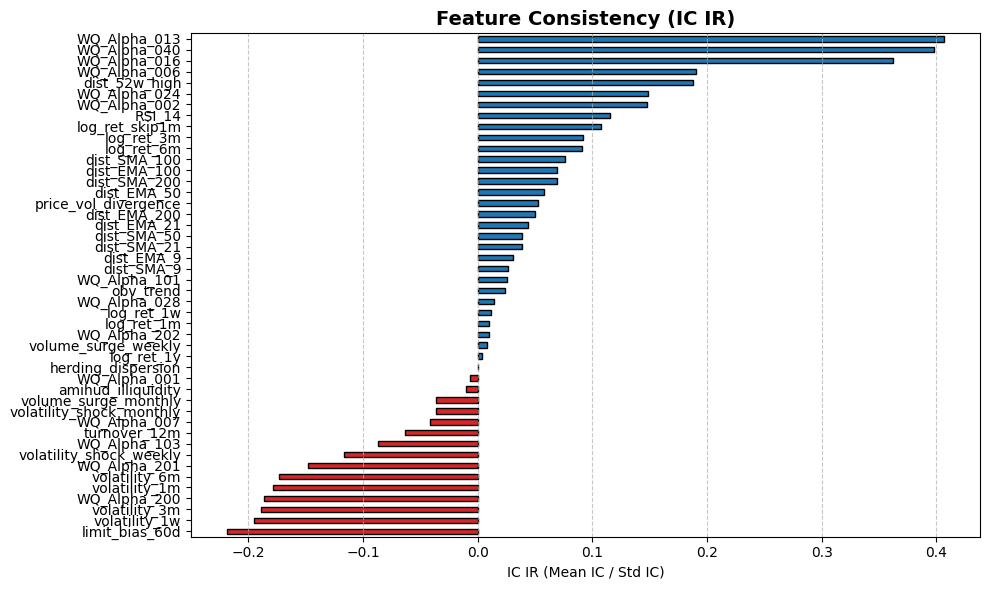

In [9]:
# IC IR bar chart — visual summary of signal quality per feature
ic_ir_results = ev.plot_feature_ir(df, features)

## 2.5 Redundancy Pruning — Correlation Heatmap

Highly correlated features carry redundant information and can destabilize the ranker by splitting importance across collinear signals.

**Pruning rule:** For any pair within the same feature group with Spearman correlation ≥ 0.75, drop the one with the lower IC IR.

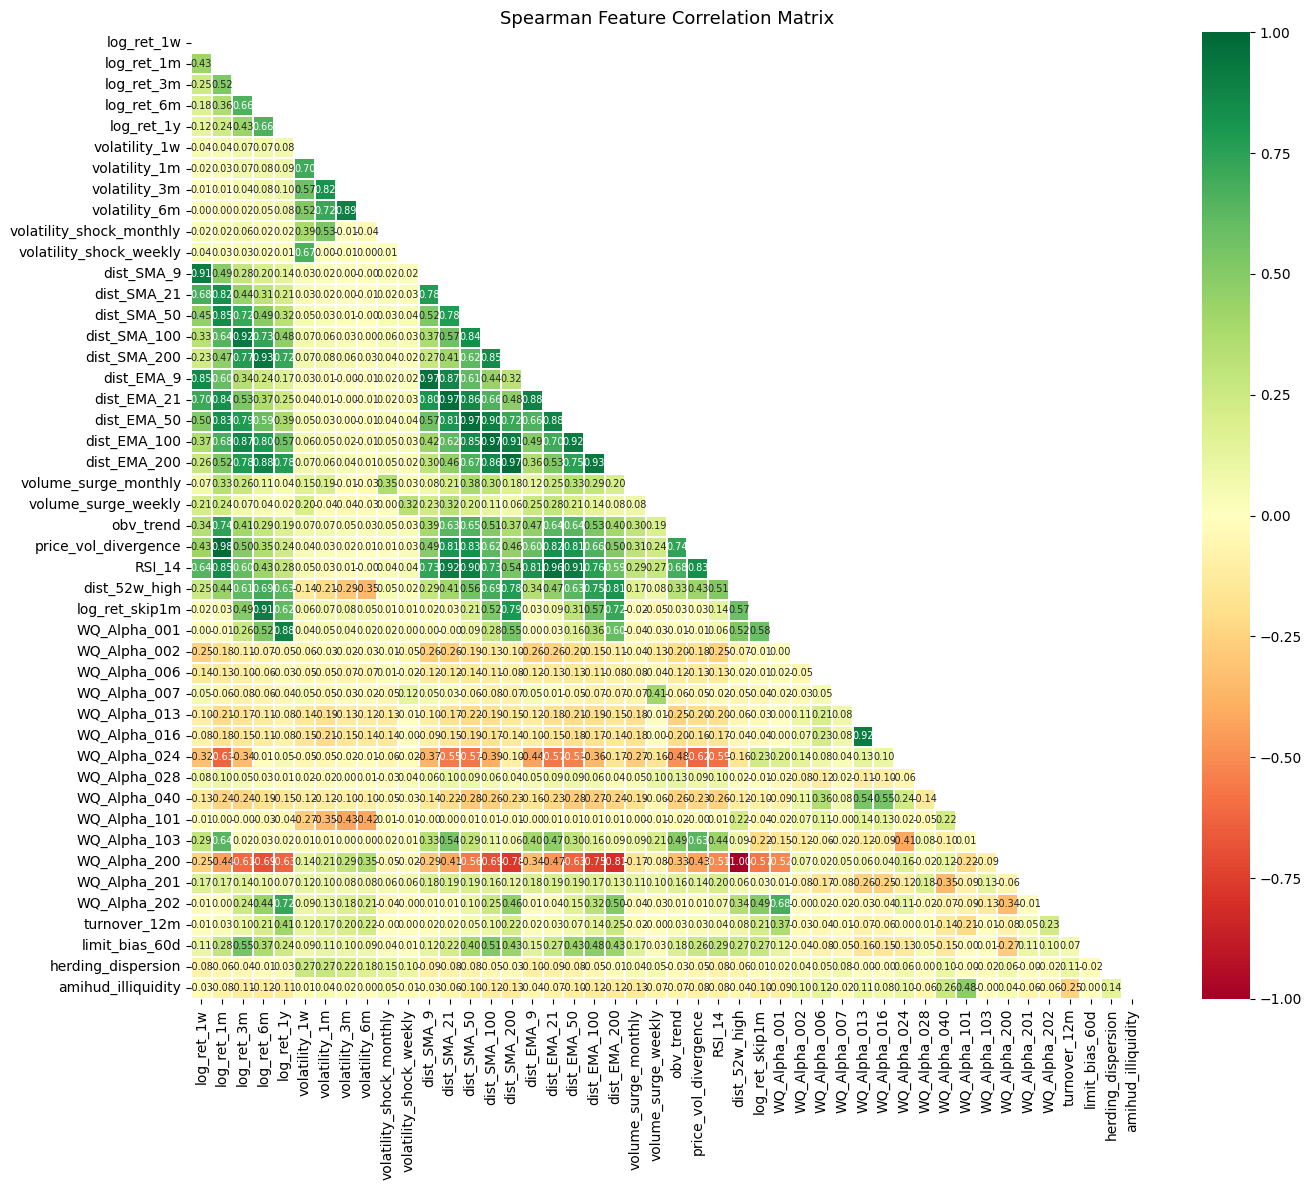

In [10]:
# Compute Spearman correlation matrix across all candidate features
df_clean = df[features].dropna()
corr_matrix, _ = spearmanr(df_clean)
corr_df = pd.DataFrame(corr_matrix, index=features, columns=features)

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Spearman Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# Drop the weaker feature (lower IC IR) from each highly-correlated pair within the same group
THRESHOLD    = 0.75
to_drop      = set()
FEATURE_GROUPS = fs.FEATURE_GROUPS

for group_name, group_features in FEATURE_GROUPS.items():
    group_features = [f for f in group_features if f in corr_df.index]
    print(f'\n── Group: {group_name} ({len(group_features)} features) ──')

    for i in range(len(group_features)):
        for j in range(i + 1, len(group_features)):
            feat_i, feat_j = group_features[i], group_features[j]
            if abs(corr_df.loc[feat_i, feat_j]) >= THRESHOLD:
                ir_i = ic_df.loc[feat_i, 'ic_ir']
                ir_j = ic_df.loc[feat_j, 'ic_ir']
                drop = feat_j if ir_i >= ir_j else feat_i
                to_drop.add(drop)
                print(f'  Corr({feat_i}, {feat_j}) = {corr_df.loc[feat_i, feat_j]:.2f} → drop "{drop}"')

all_group_features = [f for feats in FEATURE_GROUPS.values() for f in feats]
clean_features = [f for f in all_group_features if f not in to_drop]
print(f'\nAfter deduplication: {len(clean_features)}/{len(all_group_features)} features kept')


── Group: returns (5 features) ──

── Group: volatility (6 features) ──
  Corr(volatility_1m, volatility_3m) = 0.82 → drop "volatility_3m"
  Corr(volatility_3m, volatility_6m) = 0.89 → drop "volatility_3m"

── Group: moving_average (10 features) ──
  Corr(dist_SMA_9, dist_SMA_21) = 0.78 → drop "dist_SMA_9"
  Corr(dist_SMA_9, dist_EMA_9) = 0.97 → drop "dist_SMA_9"
  Corr(dist_SMA_9, dist_EMA_21) = 0.80 → drop "dist_SMA_9"
  Corr(dist_SMA_21, dist_SMA_50) = 0.78 → drop "dist_SMA_21"
  Corr(dist_SMA_21, dist_EMA_9) = 0.87 → drop "dist_EMA_9"
  Corr(dist_SMA_21, dist_EMA_21) = 0.97 → drop "dist_SMA_21"
  Corr(dist_SMA_21, dist_EMA_50) = 0.81 → drop "dist_SMA_21"
  Corr(dist_SMA_50, dist_SMA_100) = 0.84 → drop "dist_SMA_50"
  Corr(dist_SMA_50, dist_EMA_21) = 0.86 → drop "dist_SMA_50"
  Corr(dist_SMA_50, dist_EMA_50) = 0.97 → drop "dist_SMA_50"
  Corr(dist_SMA_50, dist_EMA_100) = 0.85 → drop "dist_SMA_50"
  Corr(dist_SMA_100, dist_SMA_200) = 0.85 → drop "dist_SMA_200"
  Corr(dist_SMA_100, d

In [12]:
# Apply IC IR threshold — drop features with |IC IR| <= 0.02
clean_features = ic_ir_results.loc[
    clean_features
].loc[
    np.abs(ic_ir_results.loc[clean_features, 'IC IR']) > 0.02
].index.tolist()

print(f'Final feature count: {len(clean_features)}')
print(clean_features)

Final feature count: 24
['log_ret_3m', 'log_ret_6m', 'volatility_1w', 'volatility_1m', 'volatility_6m', 'volatility_shock_monthly', 'volatility_shock_weekly', 'dist_SMA_100', 'volume_surge_monthly', 'obv_trend', 'price_vol_divergence', 'RSI_14', 'WQ_Alpha_002', 'WQ_Alpha_006', 'WQ_Alpha_007', 'WQ_Alpha_013', 'WQ_Alpha_024', 'WQ_Alpha_040', 'WQ_Alpha_101', 'WQ_Alpha_103', 'WQ_Alpha_200', 'WQ_Alpha_201', 'dist_52w_high', 'log_ret_skip1m']


## 2.6 Save Processed Data

In [14]:
OUTPUT_PATH = '../data/featured_data.parquet'
df.to_parquet(OUTPUT_PATH, index=False)

print(f'Saved to {OUTPUT_PATH}')
print(f'Shape: {df.shape}')

Saved to ../data/featured_data.parquet
Shape: (605950, 72)


## Summary

| Step | Input | Output |
|---|---|---|
| Feature construction | `market_data.parquet` | ~30 candidate features + targets |
| IC/IR analysis | Candidate features | IC IR scores per feature |
| Correlation pruning | ~30 candidates | Deduplicated subset |
| Save | Full dataframe | `data/featured_data.parquet` |

**Next step →** `03_Model_Training.ipynb` — walk-forward CV to generate honest OOS predictions.